# **Part 0 : Deliverable Guidelines**

The deliverable must consist of:
- One single `.ipynb` notebook (Python notebook)
- A PDF version exported from the notebook
- If possible, the dataset used should also be attached, or the data source should be clearly referenced in the notebook

https://huggingface.co/datasets/FinanceInc/auditor_sentiment

## **Timeline**

The final deliverable is expected **??**.



**Data Requirements**
The data must be taken from **Hugging Face**, and the topic must be related to:
- Finance
- Insurance
- Risk

## **Expectations**

You are expected to clearly explain the context and justify **why this use case is relevant**.

## **Why this problem?**


Explain:
- What the problem is
- Why it matters
- Why it is worth studying

## **What is the data?**

Explain:
- What the dataset is
- Why this dataset was chosen
- How the data is prepared
- Why the data is suitable for the problem

## **Supervised Model**


You must build a **supervised learning model** using the chosen data type, such as:
- Image
- Audio
- Text
- etc.

Minimum expected:
- Decision Tree  
**or**
- Random Forest

## **Study and Interpretation of Results ⭐ (Most Important)**


You are expected to analyze and interpret the model results:

- Is the model performance satisfactory?
- How can the results be interpreted?
- Why are the results good or bad?
- What could have been improved?
- What are the limitations of the results?
- Are there any constraints such as:
  - High model cost
  - Ethical risks
  - Bias
  - Practical limitations

## **Evaluation Criteria**

- **6 to 8 points** → Quality of explanations  
- **2 points** → Quality of code  
- **4 to 6 points** → Depth of the work  
- **6 to 8 points** → Respect of instructions and requirements  

# **Part 1 : Data Preperation**

## **1.1 - Import Data Set**

We first found and imported our financial_news_sentiments data set from hungging face by connecting to our account with a token.

In [67]:
from datasets import load_dataset
ds = load_dataset("Tydyannes69/finance-financialmodelingprep-stock-news-sentiments-rss-feed")
ds = load_dataset("Tydyannes69/auditor_sentiment")

README.md: 0.00B [00:00, ?B/s]

dataset_infos.json:   0%|          | 0.00/800 [00:00<?, ?B/s]

data/train-00000-of-00001.parquet:   0%|          | 0.00/327k [00:00<?, ?B/s]

data/test-00000-of-00001.parquet:   0%|          | 0.00/80.9k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/3877 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/969 [00:00<?, ? examples/s]

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Then we wanted to have a look at the data set to see if the importation functioned. So we decided to create a CSV file to be able to visulize it.

In [88]:
import pandas as pd

df = ds["train"].to_pandas()

print(df.head())
print(df.columns)

df['sentence'].to_csv("test.csv", index=False)

                                            sentence  label
0  Altia 's operating profit jumped to EUR 47 mil...      2
1  The agreement was signed with Biohit Healthcar...      2
2  Kesko pursues a strategy of healthy , focused ...      2
3  Vaisala , headquartered in Helsinki in Finland...      1
4  Also , a six-year historic analysis is provide...      1
Index(['sentence', 'label'], dtype='object')


## **1.2 - Descriptive Statistics**

In [89]:
# Nombre de lignes et colonnes
num_rows = ds["train"].num_rows
num_cols = len(ds["train"].column_names)

print(f"Number of rows: {num_rows}")
print(f"Number of columns: {num_cols}")
print(f"Names of the Columns: {ds['train'].column_names}")

Number of rows: 3877
Number of columns: 2
Names of the Columns: ['sentence', 'label']


Since the dataset contained a large number of observations, we decided to focus on the top 10 companies by market capitalization, as well as Bitcoin (BTC) and Ethereum (ETH).

This choice was motivated by the next step of our project, which involves web scraping. Processing the full dataset of 140,000 entries would be too computationally intensive given our available resources.

Therefore, we narrowed the dataset down to the selected symbols and reduced it to approximately 1,000 entries to ensure efficient and manageable processing.

We chose the top 10 companies by market capitalization because these are symbols that everyone knows and because we personnaly like them.

In [90]:
print(df['label'].value_counts())

label
1    2320
2    1077
0     480
Name: count, dtype: int64


In [ ]:
symbols_list = ["NVDA", "AAPL", "GOOG", "MSFT", "AMZN", "META", "AVGO", "TSLA", "BRK-A", "WMT", "BTC-USD", "ETH-USD"]
df = df[df["symbol"].isin(symbols_list)]
symbol_counts_filtered = df["symbol"].value_counts()

print("📊 Symbol distribution (filtered):")
print(symbol_counts_filtered)

📊 Symbol distribution (filtered):
symbol
TSLA       2909
BTC-USD    1842
NVDA       1255
AAPL       1221
MSFT       1210
AMZN        775
META        647
ETH-USD     480
GOOG        226
WMT         183
AVGO        175
BRK-A        80
Name: count, dtype: int64


We now have a data set composed of 11 003 entries and 9 columns.

In [91]:
print(df.shape)

(3877, 2)


We now analyze the number of articles published per month in 2022 and 2023 with a pivot table.

In [61]:
df["publishedDate"] = pd.to_datetime(df["publishedDate"], utc=True)
df["year"] = df["publishedDate"].dt.year
df["month"] = df["publishedDate"].dt.month
pivot_table = df.pivot_table(index="year", columns="month", aggfunc="size", fill_value=0)
pivot_table

month,1,2,3,4,5,6,7,8,9,10,11,12
year,,,,,,,,,,,,
2022,0,0,0,0,0,0,0,7490,11738,11788,10679,9991
2023,10596,6708,10480,7099,11084,10169,10247,11976,10439,1516,0,0


In [71]:
df.head()

,sentence,label
0,Altia 's operating profit jumped to EUR 47 mil...,2
1,The agreement was signed with Biohit Healthcar...,2
2,"Kesko pursues a strategy of healthy , focused ...",2
3,"Vaisala , headquartered in Helsinki in Finland...",1
4,"Also , a six-year historic analysis is provide...",1


## Description of the variable "sentimentScore"

In [62]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
df['sentimentScaled'] = scaler.fit_transform(df[['sentimentScore']])

print("The mean is",round(df['sentimentScaled'].mean(),2))
print("The median is",round(df['sentimentScaled'].median(),2))

The mean is 0.0
The median is 0.43


In [64]:
print(df['sentimentScore'].quantile([0.1, 0.2,0.25,0.3,0.4,0.5,0.6,0.7,0.75,0.8,0.9]))

0.10   -0.1027
0.20    0.8074
0.25    0.8979
0.30    0.9381
0.40    0.9714
0.50    0.9852
0.60    0.9923
0.70    0.9959
0.75    0.9971
0.80    0.9979
0.90    0.9991
Name: sentimentScore, dtype: float64


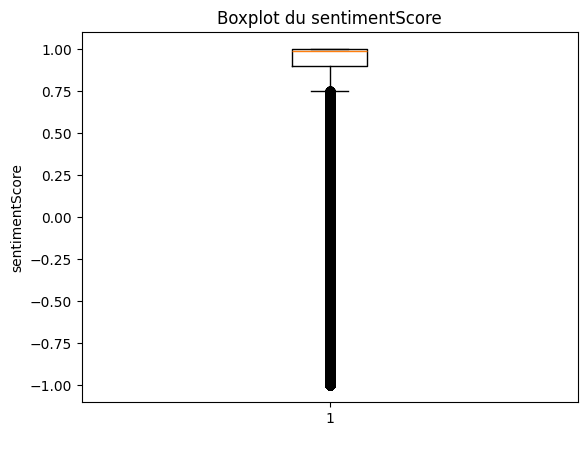

In [65]:
import matplotlib.pyplot as plt

plt.figure()
plt.boxplot(df['sentimentScore'].dropna())
plt.title("Boxplot du sentimentScore")
plt.ylabel("sentimentScore")
plt.xlabel(" ")
plt.show()

<Figure size 1500x600 with 0 Axes>

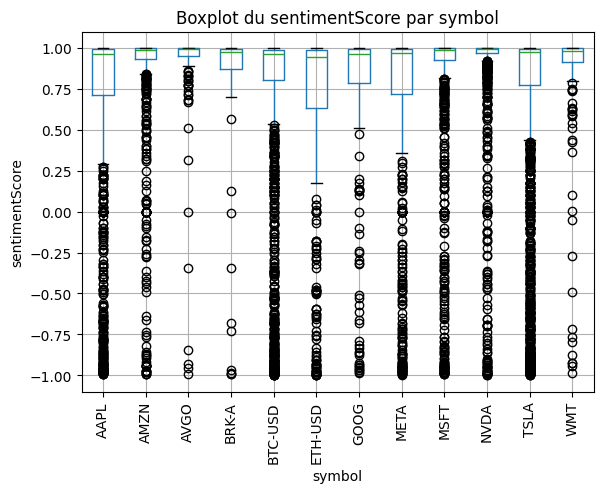

In [ ]:
# top 10 symbols les plus présents
plt.figure(figsize=(15, 6))

df_sorted = df.sort_values("symbol")

df_sorted.boxplot(column='sentimentScore', by='symbol')

plt.title("Boxplot du sentimentScore par symbol")
plt.suptitle("")
plt.xlabel("symbol")
plt.ylabel("sentimentScore")
plt.xticks(rotation=90)

plt.show()

## **1.3 - Cleaning and Scrapping Data Set**

Since there were some columns that we did not need to use in our analysis we decided to remove them to be able to lighten our dataset.

In [ ]:
import pandas as pd
import numpy as np

# convertir en date (important)
df["publishedDate"] = pd.to_datetime(df["publishedDate"]).dt.date

def sample_per_day(group):
    symbols = group["symbol"].unique()

    # shuffle pour éviter biais
    np.random.shuffle(symbols)

    selected_rows = []

    for sym in symbols:
        rows = group[group["symbol"] == sym]
        selected_rows.append(rows.sample(1))

        if len(selected_rows) == 2:
            break

    # si pas assez de symbols → compléter
    if len(selected_rows) < 2:
        remaining = group.drop(pd.concat(selected_rows).index)
        extra = remaining.sample(2 - len(selected_rows), replace=True)
        selected_rows.append(extra)

    return pd.concat(selected_rows)

df_sampled = df.groupby("publishedDate", group_keys=False).apply(sample_per_day)

df_sampled = df_sampled.reset_index(drop=True)

ValueError: a must be greater than 0 unless no samples are taken

After cleaning our dataset, we saw that our column text which represents the main content of our dataset was quite short anbd did not represent fully the content of the aricle. To bypass this problem we came with a solution of web scrapping every article of the data set to get the full content of the article. We created then a new column named "xxx". After a few trys we came up with this code that took about xxx mins to execute

In [ ]:
# =========================
# 0. INSTALL AUTO (SAFE)
# =========================
import importlib
import subprocess
import sys

def install(package, import_name=None):
    try:
        importlib.import_module(import_name or package)
    except ImportError:
        subprocess.check_call([sys.executable, "-m", "pip", "install", package])

install("newspaper3k", "newspaper")
install("beautifulsoup4", "bs4")
install("tqdm")
install("lxml")
install("lxml_html_clean")
install("nltk")

import nltk
nltk.download('punkt')

# =========================
# 1. IMPORTS
# =========================
import pandas as pd
import requests
from bs4 import BeautifulSoup
from newspaper import Article
from tqdm import tqdm
import re

# =========================
# 2. LOAD DATA
# =========================
df = pd.read_csv("finance_news.csv")

# =========================
# 3. CLEAN BASIQUE
# =========================
def clean_text(text):
    if text:
        text = re.sub(r'\s+', ' ', text)
        text = re.sub(r'\n+', ' ', text)
        return text.strip()
    return None

# =========================
# 4. SCRAPING NEWSPAPER
# =========================
def scrape_newspaper(url):
    try:
        article = Article(url)
        article.download()
        article.parse()
        return article.text
    except:
        return None

# =========================
# 5. SCRAPING BS4 CLEAN
# =========================
def scrape_bs4(url):
    try:
        headers = {"User-Agent": "Mozilla/5.0"}
        response = requests.get(url, headers=headers, timeout=10)

        if response.status_code != 200:
            return None

        soup = BeautifulSoup(response.text, "html.parser")

        # supprimer bruit structurel
        for tag in soup(["script", "style", "header", "footer", "nav", "aside", "form"]):
            tag.decompose()

        # zone article
        article = soup.find("article")

        if not article:
            article = soup.find("div", class_=lambda x: x and any(
                word in x.lower() for word in ["content", "article", "main", "body"]
            ))

        if not article:
            article = soup

        paragraphs = article.find_all("p")

        clean_paragraphs = []

        blacklist = [
            "newsletter", "inscription", "subscribe",
            "email", "contact", "cookies",
            "advertisement", "sponsored", "promo"
        ]

        for p in paragraphs:
            text = p.get_text(strip=True)

            if len(text) < 50:
                continue

            if any(word in text.lower() for word in blacklist):
                continue

            if re.search(r'\S+@\S+', text):
                continue

            if re.search(r'\+?\d[\d\s\-]{8,}', text):
                continue

            if text.isupper():
                continue

            if text.lower().startswith(("par ", "by ")):
                continue

            clean_paragraphs.append(text)

        text = " ".join(clean_paragraphs)

        return text if len(text) > 200 else None

    except:
        return None

# =========================
# 6. CLEAN AVANCÉ (🔥 KEY)
# =========================
def advanced_clean(text):
    import re

    if not text:
        return None

    blocks = re.split(r'(?<=\.)\s+', text)

    blacklist = [
        "click here", "subscribe", "newsletter",
        "privacy policy", "advertisement",
        "copy and paste", "call now"
    ]

    clean_blocks = []

    for block in blocks:
        b = block.lower()

        # ❌ supprimer uniquement vrai bruit
        if any(word in b for word in blacklist):
            continue

        # ❌ supprimer liens
        if "http" in b or "www." in b:
            continue

        # ❌ supprimer email / tel
        if re.search(r'\S+@\S+', block):
            continue
        if re.search(r'\+?\d[\d\s\-]{8,}', block):
            continue

        # ❗ IMPORTANT : NE PAS supprimer contenu corporate/juridique
        # (on a supprimé ces règles)

        # ✅ garder blocs suffisamment informatifs
        if len(block.strip()) > 30:
            clean_blocks.append(block.strip())

    text = " ".join(clean_blocks)
    text = re.sub(r'\s+', ' ', text)

    return text if len(text) > 200 else None
# =========================
# 7. PIPELINE FINAL
# =========================
def get_article_content(url):
    if pd.isna(url):
        return None

    text = scrape_newspaper(url)

    if not text or len(text) < 200:
        text = scrape_bs4(url)

    text = clean_text(text)
    text = advanced_clean(text)

    return text

# =========================
# 8. TEST SUR 10 LIGNES
# =========================
df_sample = df.head(1000).copy()

tqdm.pandas()
df_sample["contenu_article"] = df_sample["url"].progress_apply(get_article_content)

# =========================
# 9. SAVE
# =========================
df_sample.to_csv("finance_news_sample_clean.csv", index=False)

print("✅ Scraping clean terminé sur 1000 lignes !")

100%|██████████| 10/10 [00:12<00:00,  1.22s/it]


✅ Scraping terminé ! Fichier : finance_news_enriched.csv
